# Denoising RAF-DB faces with DnCNN

Webcams and low-light cameras add noise to face images. This notebook:

1. Adds synthetic **additive white Gaussian noise** to the RAF-DB color dataset.
2. Denoises the faces with **DnCNN** (Zhang et al., 2017), using the authors' pretrained color model and a version fine-tuned on RAF-DB faces.
3. Measures denoising quality (PSNR, SSIM) at three noise levels.
4. Measures how noise hurts the three RAF-DB emotion classifiers (ResNet-18, DenseNet-121, EfficientNet-B0), and how much denoising recovers.

In [1]:
import os
import copy
import json
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device configuration: NVIDIA GPU (Kaggle/Colab) -> Apple Silicon GPU -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Accelerating on: {device}")

Accelerating on: mps


In [2]:
# RAF-DB color dataset laid out as <data_dir>/train/1..7 and <data_dir>/test/1..7
# Uses the Kaggle input when running on Kaggle, otherwise the local copy in ../data/raf-db
kaggle_dir = '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET'
data_dir = kaggle_dir if os.path.isdir(kaggle_dir) else '../data/raf-db'

# Fine-tuning uses random 40x40 patches, like the original DnCNN training
patch_size = 40

# Images stay in [0, 1] with no ImageNet normalization: the denoiser works on raw pixel values
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomCrop(patch_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]),
    'test': transforms.ToTensor(),  # full 100x100 test images
}

image_datasets = {x: datasets.ImageFolder(f'{data_dir}/{x}', data_transforms[x]) for x in ['train', 'test']}
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=128, shuffle=True, num_workers=2, persistent_workers=True),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False, num_workers=2, persistent_workers=True),
}

# RAF-DB label meanings for folders '1'..'7'
emotion_names = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Anger', 'Neutral']

# Set these to small numbers for a quick test run; None uses the whole dataset
max_train_batches = None
max_test_batches = None

print(f"Train images: {len(image_datasets['train'])}, Test images: {len(image_datasets['test'])}")

Train images: 12271, Test images: 3068


## 1. Adding noise to the dataset

Each clean image $x$ (pixel values in $[0, 1]$) gets **additive white Gaussian noise**:

$$y = \mathrm{clip}(x + n,\ 0,\ 1), \qquad n \sim \mathcal{N}(0, \sigma^2)$$

- The noise is independent for every pixel and every RGB channel.
- $\sigma$ is given on the 0–255 pixel scale (so $\sigma = 25$ means a standard deviation of 25 gray levels).
- Clipping keeps the result a valid 8-bit-range image, like a real camera frame.
- **Fine-tuning:** $\sigma$ is drawn uniformly from $[0, 55]$ for every patch, so one *blind* model handles all noise levels.
- **Testing:** fixed $\sigma \in \{15, 25, 50\}$ (light, moderate, heavy), generated with a fixed random seed so every run and every model sees exactly the same noisy test set.
- Noise is added on the fly, so the dataset on disk stays clean.

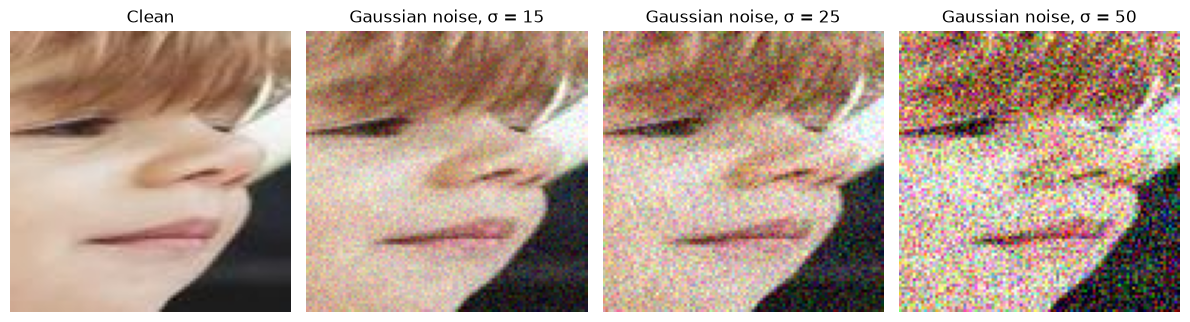

In [3]:
train_sigma_range = (0, 55)   # blind denoising: one model for all noise levels
test_sigmas = [15, 25, 50]    # evaluation noise levels on the 0-255 scale

def add_gaussian_noise(clean, sigma, generator=None):
    """Add white Gaussian noise to a batch of [0, 1] images and clip back to [0, 1].

    sigma is on the 0-255 scale: a single number or one value per image.
    Pass a seeded CPU generator (with CPU images) to get the same noise on every run.
    """
    sigma = torch.as_tensor(sigma, dtype=clean.dtype, device=clean.device).view(-1, 1, 1, 1) / 255.0
    if generator is None:
        noise = torch.randn_like(clean)
    else:
        noise = torch.randn(clean.shape, generator=generator, dtype=clean.dtype)
    return (clean + noise * sigma).clamp(0.0, 1.0)

# Show one test face at every evaluation noise level
sample, label = image_datasets['test'][image_datasets['test'].targets.index(3)]  # first Happy face
generator = torch.Generator().manual_seed(0)
plt.figure(figsize=(12, 3.4))
for i, sigma in enumerate([0] + test_sigmas):
    noisy = add_gaussian_noise(sample.unsqueeze(0), sigma, generator)[0] if sigma else sample
    plt.subplot(1, 4, i + 1)
    plt.imshow(noisy.permute(1, 2, 0).numpy())
    plt.title('Clean' if sigma == 0 else f'Gaussian noise, σ = {sigma}')
    plt.axis('off')
plt.tight_layout()
plt.savefig('noise_levels.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. DnCNN denoiser

**DnCNN** — *Beyond a Gaussian Denoiser: Residual Learning of Deep CNN for Image Denoising* (Zhang, Zuo, Chen, Meng and Zhang, IEEE Transactions on Image Processing, 2017).

- Official code: https://github.com/cszn/DnCNN
- PyTorch implementation and pretrained weights (KAIR): https://github.com/cszn/KAIR

This notebook uses the authors' **color blind** model (CDnCNN-B, `dncnn_color_blind.pth`), trained for Gaussian noise with $\sigma \in [0, 55]$:

| Layer | Operation |
| --- | --- |
| 1 | Conv 3×3, 3 → 64 channels, ReLU |
| 2–19 | Conv 3×3, 64 → 64 channels, (Batch Normalization), ReLU |
| 20 | Conv 3×3, 64 → 3 channels |

- **Residual learning:** the network predicts the noise map $\hat{n}$; the denoised image is $\hat{x} = y - \hat{n}$.
- The released weights have each Batch Normalization layer merged into the convolution before it, so the file holds 20 plain convolutions (668,227 parameters) that compute the same function.
- Padding keeps every feature map at the input size, so the model works on any image size, including 100×100 faces.

The pretrained model is then **fine-tuned on RAF-DB face patches** so it adapts to faces.

In [4]:
class DnCNN(nn.Module):
    """DnCNN (Zhang et al., 2017) with Batch Normalization merged into the convolutions, as in KAIR's released weights.

    Predicts the noise map and returns the noisy input minus that noise.
    """

    def __init__(self, channels=3, depth=20, features=64):
        super().__init__()
        layers = [nn.Conv2d(channels, features, 3, padding=1), nn.ReLU(inplace=True)]
        for _ in range(depth - 2):
            layers += [nn.Conv2d(features, features, 3, padding=1), nn.ReLU(inplace=True)]
        layers.append(nn.Conv2d(features, channels, 3, padding=1))
        self.model = nn.Sequential(*layers)  # attribute name matches the KAIR checkpoint keys

    def forward(self, noisy):
        return noisy - self.model(noisy)

weights_url = 'https://github.com/cszn/KAIR/releases/download/v1.0/dncnn_color_blind.pth'
weights_path = 'dncnn_color_blind.pth'
if not os.path.exists(weights_path):
    torch.hub.download_url_to_file(weights_url, weights_path)

pretrained = DnCNN()
pretrained.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
pretrained = pretrained.to(device).eval()
print(f"DnCNN parameters: {sum(p.numel() for p in pretrained.parameters()):,}")

DnCNN parameters: 668,227


In [5]:
def psnr(output, target):
    """Peak signal-to-noise ratio in dB for each image in a [0, 1] batch."""
    mse = ((output - target) ** 2).flatten(1).mean(1)
    return 10 * torch.log10(1.0 / mse.clamp_min(1e-10))

def ssim(output, target, window_size=11, sigma=1.5):
    """Structural similarity for each image (11x11 Gaussian window), averaged over RGB channels."""
    channels = output.shape[1]
    coords = torch.arange(window_size, dtype=output.dtype, device=output.device) - window_size // 2
    g = torch.exp(-coords ** 2 / (2 * sigma ** 2))
    g = g / g.sum()
    window = (g[:, None] * g[None, :]).repeat(channels, 1, 1, 1)
    blur = lambda x: F.conv2d(x, window, groups=channels)
    mu_x, mu_y = blur(output), blur(target)
    var_x = blur(output * output) - mu_x ** 2
    var_y = blur(target * target) - mu_y ** 2
    cov = blur(output * target) - mu_x * mu_y
    c1, c2 = 0.01 ** 2, 0.03 ** 2
    ssim_map = ((2 * mu_x * mu_y + c1) * (2 * cov + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2))
    return ssim_map.flatten(1).mean(1)

def evaluate_denoisers(denoisers, sigma, max_batches=None):
    """Average PSNR/SSIM of the noisy test images and of each denoiser's output at one noise level."""
    generator = torch.Generator().manual_seed(sigma)  # same noisy test set on every call
    totals = {name: {'psnr': 0.0, 'ssim': 0.0} for name in ['noisy', *denoisers]}
    count = 0
    with torch.no_grad():
        for i, (clean, _) in enumerate(dataloaders['test']):
            if max_batches is not None and i >= max_batches:
                break
            noisy = add_gaussian_noise(clean, sigma, generator).to(device)
            clean = clean.to(device)
            outputs = {'noisy': noisy}
            outputs.update({name: model(noisy).clamp(0.0, 1.0) for name, model in denoisers.items()})
            for name, images in outputs.items():
                totals[name]['psnr'] += psnr(images, clean).sum().item()
                totals[name]['ssim'] += ssim(images, clean).sum().item()
            count += clean.size(0)
    return {name: {k: v / count for k, v in metrics.items()} for name, metrics in totals.items()}

baseline = evaluate_denoisers({'pretrained': pretrained}, 25, max_batches=16 if max_test_batches is None else max_test_batches)
print(f"Pretrained DnCNN at σ=25 (512 test images): {baseline['noisy']['psnr']:.2f} dB noisy -> {baseline['pretrained']['psnr']:.2f} dB denoised")

Pretrained DnCNN at σ=25 (512 test images): 20.56 dB noisy -> 31.77 dB denoised


## 3. Fine-tuning DnCNN on RAF-DB faces

The pretrained model is fine-tuned on random 40×40 patches of RAF-DB training faces, each with its own random noise level $\sigma \in [0, 55]$. The loss is the mean squared error between the denoised and clean patch.

The learning rate is kept small (Adam, 1e-5) with a 50-step warmup and cosine decay. Adam's first steps move every weight by roughly the full learning rate, and at 1e-4 that destroyed the pretrained model within a few steps (test PSNR fell from 32 dB to 22 dB).

In [6]:
epochs = 8
denoiser = copy.deepcopy(pretrained)
criterion = nn.MSELoss()
optimizer = optim.Adam(denoiser.parameters(), lr=1e-5)

# Linear warmup for the first 50 steps, then cosine decay over the remaining steps
steps_per_epoch = len(dataloaders['train']) if max_train_batches is None else max_train_batches
total_steps = epochs * steps_per_epoch
warmup_steps = min(50, total_steps)
scheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lambda step: min(1.0, (step + 1) / warmup_steps) * 0.5 * (1 + math.cos(math.pi * step / total_steps)),
)

In [7]:
def finetune_denoiser(num_epochs):
    history = {'train_mse': [], 'val_psnr': []}
    val_batches = 16 if max_test_batches is None else max_test_batches  # 512 test images per check

    for epoch in range(num_epochs):
        epoch_start = time.time()
        denoiser.train()
        running_loss, seen = 0.0, 0

        for i, (clean, _) in enumerate(dataloaders['train']):
            if max_train_batches is not None and i >= max_train_batches:
                break
            clean = clean.to(device, non_blocking=True)
            # A different random noise level for every patch
            sigma = torch.empty(clean.size(0), device=device).uniform_(*train_sigma_range)
            noisy = add_gaussian_noise(clean, sigma)

            optimizer.zero_grad()
            loss = criterion(denoiser(noisy), clean)
            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * clean.size(0)
            seen += clean.size(0)

        denoiser.eval()
        val = evaluate_denoisers({'fine-tuned': denoiser}, 25, max_batches=val_batches)
        history['train_mse'].append(running_loss / seen)
        history['val_psnr'].append(val['fine-tuned']['psnr'])
        print(f"Epoch {epoch+1}/{num_epochs} | train MSE: {running_loss / seen:.5f} | "
              f"test PSNR at σ=25: {val['fine-tuned']['psnr']:.2f} dB (pretrained: {baseline['pretrained']['psnr']:.2f} dB) | "
              f"time: {time.time() - epoch_start:.0f}s")
    return history

train_start = time.time()
history = finetune_denoiser(epochs)
training_minutes = (time.time() - train_start) / 60
denoiser.eval()
print(f"Fine-tuning time: {training_minutes:.1f} min")

Epoch 1/8 | train MSE: 0.00088 | test PSNR at σ=25: 32.00 dB (pretrained: 31.77 dB) | time: 44s


Epoch 2/8 | train MSE: 0.00083 | test PSNR at σ=25: 32.10 dB (pretrained: 31.77 dB) | time: 43s


Epoch 3/8 | train MSE: 0.00081 | test PSNR at σ=25: 32.13 dB (pretrained: 31.77 dB) | time: 45s


Epoch 4/8 | train MSE: 0.00081 | test PSNR at σ=25: 32.15 dB (pretrained: 31.77 dB) | time: 48s


Epoch 5/8 | train MSE: 0.00080 | test PSNR at σ=25: 32.18 dB (pretrained: 31.77 dB) | time: 60s


Epoch 6/8 | train MSE: 0.00078 | test PSNR at σ=25: 32.22 dB (pretrained: 31.77 dB) | time: 58s


Epoch 7/8 | train MSE: 0.00080 | test PSNR at σ=25: 32.22 dB (pretrained: 31.77 dB) | time: 54s


Epoch 8/8 | train MSE: 0.00079 | test PSNR at σ=25: 32.23 dB (pretrained: 31.77 dB) | time: 52s
Fine-tuning time: 6.7 min


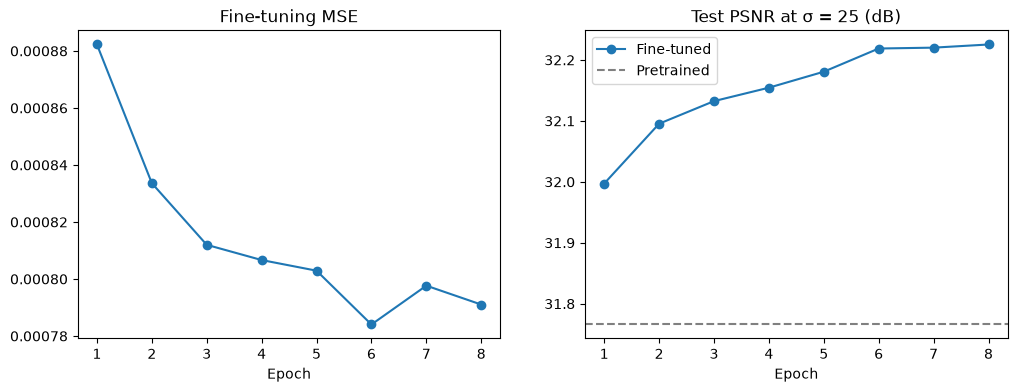

✅ Fine-tuned DnCNN saved successfully to 'dncnn_rafdb_finetuned.pth'


In [8]:
# Plot Fine-tuning History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_mse'], marker='o')
plt.title('Fine-tuning MSE')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['val_psnr'], marker='o', label='Fine-tuned')
plt.axhline(baseline['pretrained']['psnr'], color='gray', linestyle='--', label='Pretrained')
plt.title('Test PSNR at σ = 25 (dB)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Save the fine-tuned denoiser
torch.save(denoiser.state_dict(), 'dncnn_rafdb_finetuned.pth')
print("✅ Fine-tuned DnCNN saved successfully to 'dncnn_rafdb_finetuned.pth'")

## 4. Denoising quality

PSNR (higher is better) and SSIM (1.0 means identical structure) of the noisy, pretrained-denoised and fine-tuned-denoised test images, compared with the clean originals.

In [9]:
denoisers = {'pretrained': pretrained, 'fine-tuned': denoiser}
denoise_results = {}
print(f"{'':<8}{'Noisy':>16}{'Pretrained':>18}{'Fine-tuned':>18}   (PSNR dB / SSIM)")
for sigma in test_sigmas:
    denoise_results[sigma] = r = evaluate_denoisers(denoisers, sigma, max_batches=max_test_batches)
    print(f"σ = {sigma:<4}" + "".join(f"{r[name]['psnr']:>10.2f} / {r[name]['ssim']:.3f}" for name in ['noisy', 'pretrained', 'fine-tuned']))

                   Noisy        Pretrained        Fine-tuned   (PSNR dB / SSIM)


σ = 15       24.82 / 0.572     34.94 / 0.943     34.99 / 0.945


σ = 25       20.53 / 0.384     32.09 / 0.909     32.50 / 0.916


σ = 50       14.99 / 0.185     27.54 / 0.833     28.76 / 0.848


## 5. Effect on emotion recognition

The three RAF-DB classifiers from `Video Predicition/` are tested on the same test images as **clean**, **noisy**, **denoised by the pretrained DnCNN** and **denoised by the fine-tuned DnCNN**. Images get the classifiers' test preprocessing (resize to 224×224, ImageNet normalization). The resize here runs on the GPU, so clean accuracy can differ by about 0.2 points from the training notebooks, which resize with PIL.

In [10]:
def load_classifier(name):
    """Rebuild a RAF-DB classifier with its Dropout + Linear head and load its trained weights."""
    if name == 'ResNet-18':
        model = models.resnet18()
        model.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(model.fc.in_features, 7))
        weights = 'resnet18_rafdb_final.pth'
    elif name == 'DenseNet-121':
        model = models.densenet121()
        model.classifier = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(model.classifier.in_features, 7))
        weights = 'densenet121_rafdb_final.pth'
    else:
        model = models.efficientnet_b0()
        model.classifier = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(model.classifier[1].in_features, 7))
        weights = 'efficientnet_b0_rafdb_final.pth'
    model.load_state_dict(torch.load(f'../Video Predicition/{weights}', map_location=device))
    return model.to(device).eval()

classifiers = {name: load_classifier(name) for name in ['ResNet-18', 'DenseNet-121', 'EfficientNet-B0']}

imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def classifier_input(images):
    """The classifiers' test preprocessing: resize to 224x224, then ImageNet normalization."""
    images = F.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
    return (images - imagenet_mean) / imagenet_std

In [11]:
conditions = ['clean'] + [f'{kind}_{s}' for s in test_sigmas for kind in ['noisy', 'pretrained', 'fine-tuned']]
correct = {name: dict.fromkeys(conditions, 0) for name in classifiers}
generators = {s: torch.Generator().manual_seed(s) for s in test_sigmas}  # same seeds as the PSNR evaluation
total = 0

with torch.no_grad():
    for i, (clean, labels) in enumerate(dataloaders['test']):
        if max_test_batches is not None and i >= max_test_batches:
            break
        variants = {'clean': clean.to(device)}
        for s in test_sigmas:
            noisy = add_gaussian_noise(clean, s, generators[s]).to(device)
            variants[f'noisy_{s}'] = noisy
            variants[f'pretrained_{s}'] = pretrained(noisy).clamp(0.0, 1.0)
            variants[f'fine-tuned_{s}'] = denoiser(noisy).clamp(0.0, 1.0)
        labels = labels.to(device)
        total += labels.size(0)
        for name, model in classifiers.items():
            for condition, images in variants.items():
                correct[name][condition] += (model(classifier_input(images)).argmax(1) == labels).sum().item()

accuracy = {name: {c: correct[name][c] / total for c in conditions} for name in classifiers}

print(f"Test accuracy on {total} RAF-DB test images\n")
for s in test_sigmas:
    print(f"σ = {s}")
    print(f"  {'Model':<16}{'Clean':>8}{'Noisy':>9}{'Pretrained':>12}{'Fine-tuned':>12}")
    for name, acc in accuracy.items():
        print(f"  {name:<16}{acc['clean']:>8.2%}{acc[f'noisy_{s}']:>9.2%}{acc[f'pretrained_{s}']:>12.2%}{acc[f'fine-tuned_{s}']:>12.2%}")

Test accuracy on 3068 RAF-DB test images

σ = 15
  Model              Clean    Noisy  Pretrained  Fine-tuned
  ResNet-18         86.86%   81.49%      85.43%      85.40%
  DenseNet-121      87.42%   82.43%      85.79%      86.21%
  EfficientNet-B0   87.22%   56.36%      85.69%      85.85%
σ = 25
  Model              Clean    Noisy  Pretrained  Fine-tuned
  ResNet-18         86.86%   73.79%      84.39%      84.16%
  DenseNet-121      87.42%   75.95%      84.39%      84.65%
  EfficientNet-B0   87.22%   18.84%      82.95%      84.35%
σ = 50
  Model              Clean    Noisy  Pretrained  Fine-tuned
  ResNet-18         86.86%   38.43%      77.87%      78.29%
  DenseNet-121      87.42%   49.45%      78.23%      78.62%
  EfficientNet-B0   87.22%   16.56%      77.64%      78.19%


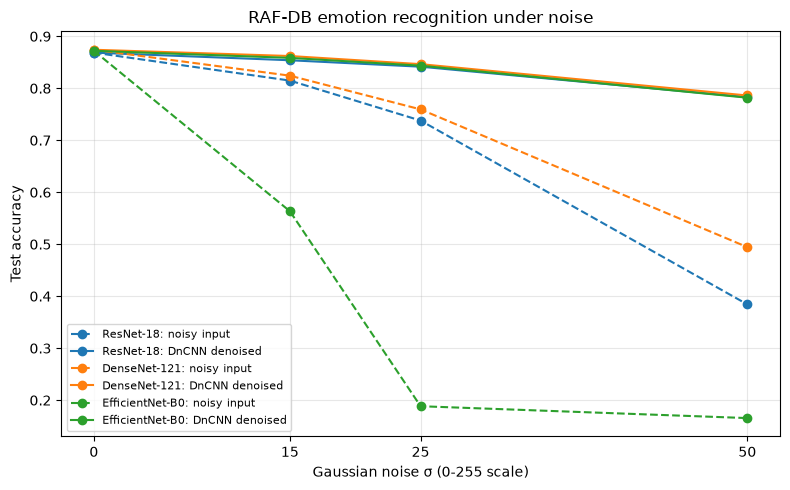

In [12]:
# Accuracy against noise level, without and with the fine-tuned DnCNN
plt.figure(figsize=(8, 5))
levels = [0] + test_sigmas
for name, acc in accuracy.items():
    line, = plt.plot(levels, [acc['clean']] + [acc[f'noisy_{s}'] for s in test_sigmas], '--o', label=f'{name}: noisy input')
    plt.plot(levels, [acc['clean']] + [acc[f'fine-tuned_{s}'] for s in test_sigmas], '-o', color=line.get_color(), label=f'{name}: DnCNN denoised')
plt.xlabel('Gaussian noise σ (0-255 scale)')
plt.ylabel('Test accuracy')
plt.title('RAF-DB emotion recognition under noise')
plt.xticks(levels)
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fer_accuracy_vs_noise.png', dpi=200, bbox_inches='tight')
plt.show()

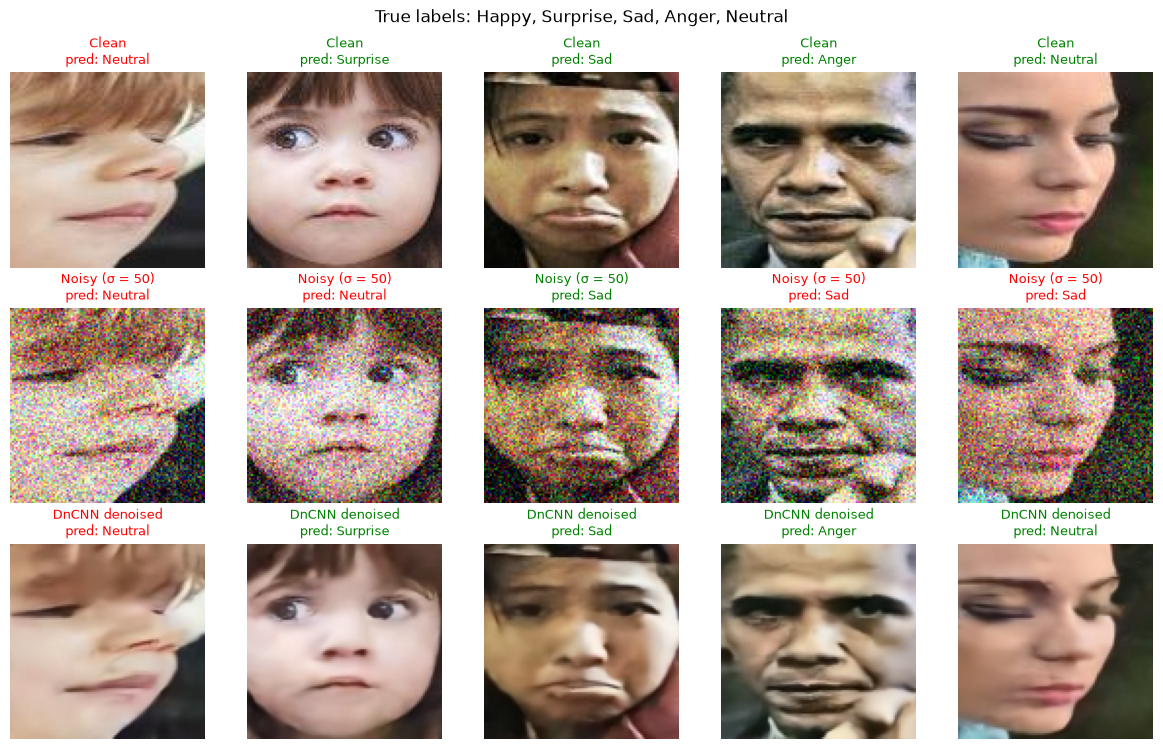

In [13]:
# Clean, noisy (σ = 50) and denoised faces with EfficientNet-B0 predictions (green = correct)
sigma = 50
test_set = image_datasets['test']
indices = [test_set.targets.index(c) for c in [3, 0, 4, 5, 6]]  # Happy, Surprise, Sad, Anger, Neutral
clean = torch.stack([test_set[i][0] for i in indices])
labels = [test_set.targets[i] for i in indices]
noisy = add_gaussian_noise(clean, sigma, torch.Generator().manual_seed(1))

with torch.no_grad():
    noisy = noisy.to(device)
    rows = {'Clean': clean.to(device), f'Noisy (σ = {sigma})': noisy, 'DnCNN denoised': denoiser(noisy).clamp(0.0, 1.0)}
    preds = {k: classifiers['EfficientNet-B0'](classifier_input(v)).argmax(1).tolist() for k, v in rows.items()}

plt.figure(figsize=(12, 7.6))
for r, (row_name, images) in enumerate(rows.items()):
    for c in range(len(indices)):
        ax = plt.subplot(3, len(indices), r * len(indices) + c + 1)
        ax.imshow(images[c].permute(1, 2, 0).cpu().numpy())
        pred = preds[row_name][c]
        ax.set_title(f"{row_name}\npred: {emotion_names[pred]}", fontsize=9,
                     color='green' if pred == labels[c] else 'red')
        ax.axis('off')
plt.suptitle('True labels: ' + ', '.join(emotion_names[l] for l in labels))
plt.tight_layout()
plt.savefig('denoising_examples.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
# Save all numbers for the README and presentation
results = {
    'dataset': 'RAF-DB',
    'test_images': total,
    'noise': {'type': 'additive white Gaussian, clipped to [0, 1]', 'train_sigma_range': list(train_sigma_range), 'test_sigmas': test_sigmas},
    'denoiser': {'model': 'DnCNN (color blind, KAIR pretrained weights)', 'depth': 20, 'features': 64,
                 'parameters': sum(p.numel() for p in denoiser.parameters()),
                 'weights_url': weights_url, 'finetune_epochs': epochs, 'finetune_steps': total_steps, 'patch_size': patch_size,
                 'finetune_minutes': round(training_minutes, 1)},
    'finetune_history': history,
    'denoising_quality': {str(s): v for s, v in denoise_results.items()},
    'classifier_accuracy': accuracy,
}
with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("✅ Results saved to 'results.json'")

✅ Results saved to 'results.json'
